In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

path_processed = os.path.join(PROJECT_ROOT, 'data', 'processed', 'ucs_satellites_cleaned.csv')
path_raw = os.path.join(PROJECT_ROOT, 'data', 'raw', 'ucs_satellites.txt')

if os.path.exists(path_processed):
    df = pd.read_csv(path_processed)
    print(f"✔ Dataset PROCESADO cargado con éxito. Dimensiones: {df.shape}")
elif os.path.exists(path_raw):
    print("⚠️ Cargando archivo BASE. Creando variables temporales para el EDA...")
    df = pd.read_csv(path_raw, sep='\t', encoding='latin-1', on_bad_lines='skip')
    
    if 'Orbit_Class_Extended' not in df.columns and 'Class of Orbit' in df.columns:
        df['Orbit_Class_Extended'] = df['Class of Orbit'].fillna('Unknown')
    
    if 'Mass_Category' not in df.columns and 'Launch Mass (kg.)' in df.columns:
        df['Launch Mass (kg.)'] = pd.to_numeric(df['Launch Mass (kg.)'].astype(str).str.replace(',', ''), errors='coerce')
        
        try:
            df['Mass_Category'] = pd.qcut(df['Launch Mass (kg.)'], q=3, labels=['Ligero', 'Medio', 'Pesado'])
        except Exception:
            print("ℹ Usando cortes fijos alternativos para las categorías de masa...")
            df['Mass_Category'] = pd.cut(df['Launch Mass (kg.)'], bins=[0, 500, 2000, np.inf], labels=['Ligero', 'Medio', 'Pesado'])
            
        df['Mass_Category'] = df['Mass_Category'].astype(str).replace('nan', 'Desconocido').fillna('Desconocido')
        
    print(f"✔ Dataset BASE cargado y adaptado con éxito. Dimensiones: {df.shape}")
else:
    print(f"❌ Archivo no encontrado en: {path_raw}")

⚠️ Cargando archivo BASE. Creando variables temporales para el EDA...
✔ Dataset BASE cargado y adaptado con éxito. Dimensiones: (7562, 69)


C:\Users\User\AppData\Local\Temp\ipykernel_25788\3882342098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Orbit_Class_Extended', palette='viridis',
C:\Users\User\AppData\Local\Temp\ipykernel_25788\3882342098.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mass_Category', palette='magma',


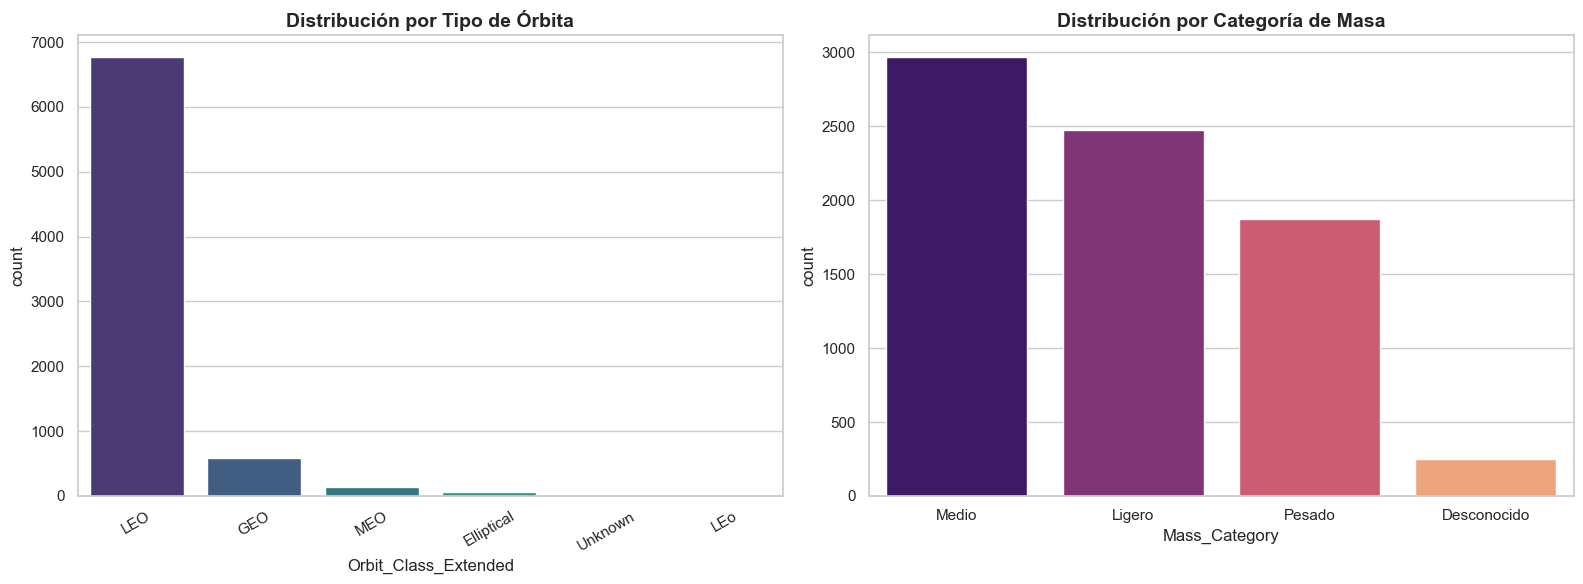

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'Orbit_Class_Extended' in df.columns:
    sns.countplot(data=df, x='Orbit_Class_Extended', palette='viridis', 
                  order=df['Orbit_Class_Extended'].value_counts().index, ax=axes[0])
    axes[0].set_title('Distribución por Tipo de Órbita', fontweight='bold', fontsize=14)
    axes[0].tick_params(axis='x', rotation=30)

if 'Mass_Category' in df.columns:
    sns.countplot(data=df, x='Mass_Category', palette='magma', 
                  order=df['Mass_Category'].value_counts().index, ax=axes[1])
    axes[1].set_title('Distribución por Categoría de Masa', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

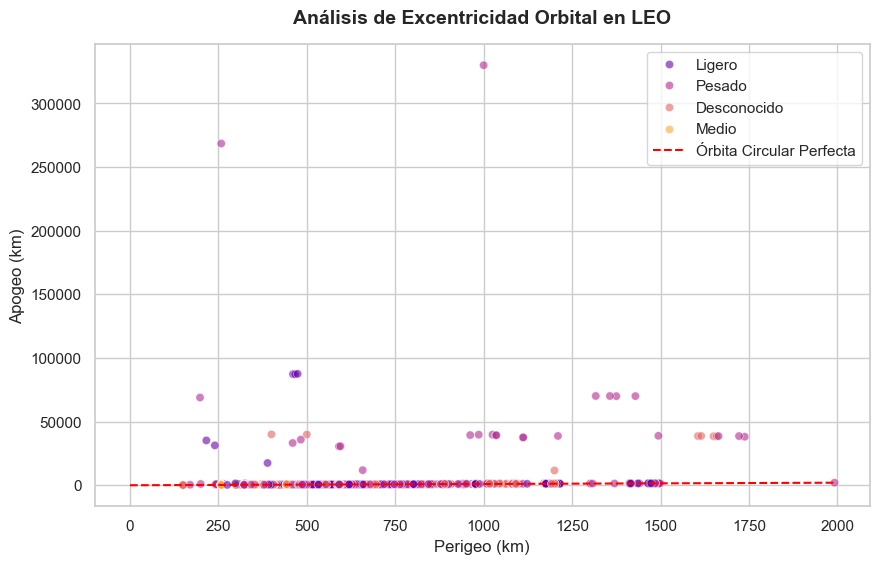

In [ ]:
df['Perigee (km)'] = pd.to_numeric(df['Perigee (km)'].astype(str).str.replace(',', ''), errors='coerce')
df['Apogee (km)'] = pd.to_numeric(df['Apogee (km)'].astype(str).str.replace(',', ''), errors='coerce')

df_leo = df[df['Perigee (km)'] < 2000].dropna(subset=['Perigee (km)', 'Apogee (km)'])

if not df_leo.empty:
    sns.scatterplot(data=df_leo, x='Perigee (km)', y='Apogee (km)', 
                    hue='Mass_Category' if 'Mass_Category' in df.columns else None, 
                    palette='plasma', alpha=0.6)
    
    max_val = int(df_leo['Perigee (km)'].max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Órbita Circular Perfecta')
    
    plt.title('Análisis de Excentricidad Orbital en LEO', fontweight='bold', pad=15, fontsize=14)
    plt.xlabel('Perigeo (km)')
    plt.ylabel('Apogeo (km)')
    plt.legend()
    plt.show()
else:
    print("⚠️ No hay suficientes datos numéricos válidos en Perigeo/Apogeo para graficar la excentricidad.")

C:\Users\User\AppData\Local\Temp\ipykernel_25788\2060034125.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')


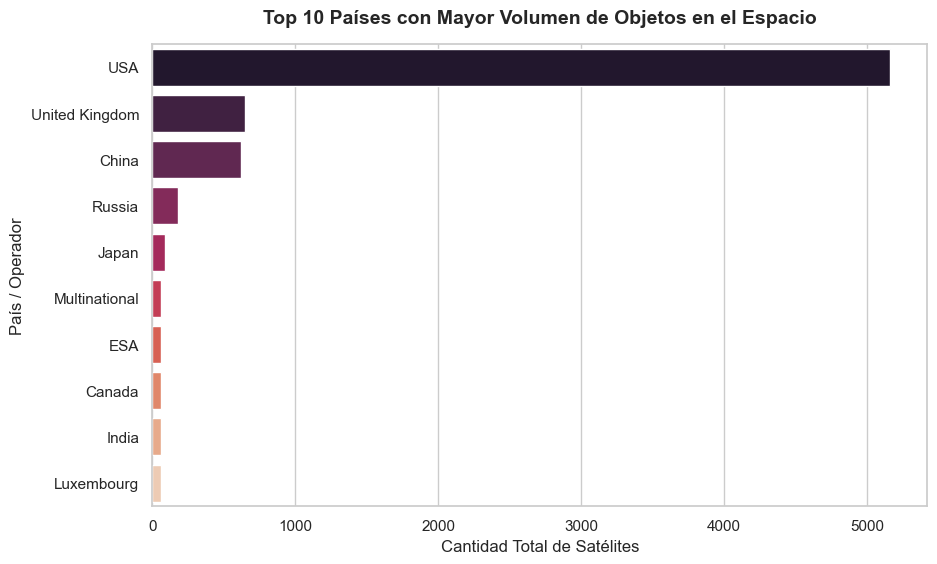

In [ ]:
df['Country of Operator/Owner'] = df['Country of Operator/Owner'].astype(str).str.strip()

df_countries = df[~df['Country of Operator/Owner'].isin(['nan', 'Unknown', ''])]

top_countries = df_countries['Country of Operator/Owner'].value_counts().head(10)

if not top_countries.empty:
    sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')
    plt.title('Top 10 Países con Mayor Volumen de Objetos en el Espacio', fontweight='bold', pad=15, fontsize=14)
    plt.xlabel('Cantidad Total de Satélites')
    plt.ylabel('País / Operador')
    plt.show()
else:
    print("❌ Error de datos: La columna 'Country of Operator/Owner' está completamente vacía o ilegible.")

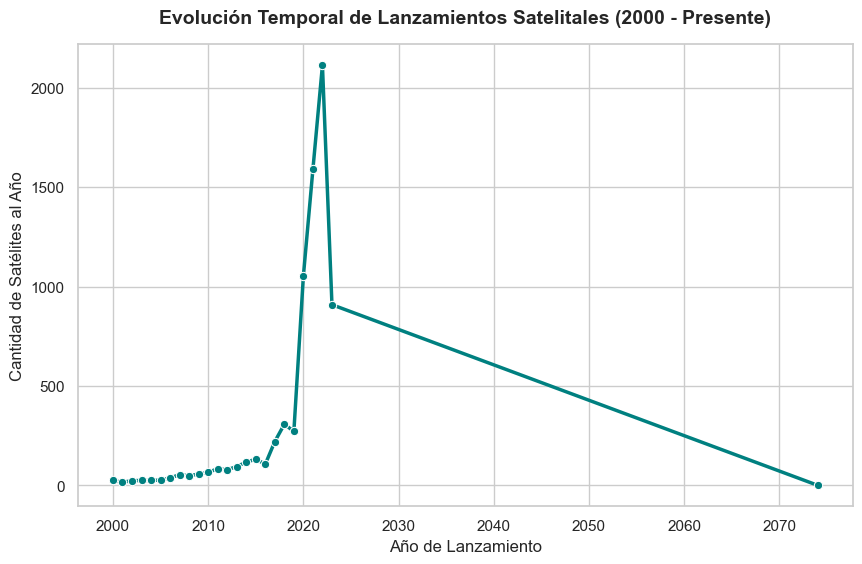

In [ ]:
df['Launch_Year'] = pd.to_datetime(df['Date of Launch'], errors='coerce', format='mixed').dt.year

conteo_anual = df.dropna(subset=['Launch_Year']).groupby('Launch_Year').size().reset_index(name='Lanzamientos')

conteo_moderno = conteo_anual[conteo_anual['Launch_Year'] >= 2000]

if not conteo_moderno.empty:
    sns.lineplot(data=conteo_moderno, x='Launch_Year', y='Lanzamientos', marker='o', color='teal', linewidth=2.5)
    plt.title('Evolución Temporal de Lanzamientos Satelitales (2000 - Presente)', fontweight='bold', pad=15, fontsize=14)
    plt.xlabel('Año de Lanzamiento')
    plt.ylabel('Cantidad de Satélites al Año')
    plt.show()
else:
    print("⚠️ No se pudieron procesar las fechas de la columna 'Date of Launch'.")